In [48]:
import torch
torch.cuda.is_available()

True

In [36]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("data/raw_data1.csv")
df2 = pd.read_csv("data/raw_data2.csv")

df1["reg_date"] = pd.to_datetime(df1["reg_date"], errors="coerce")
df2["reg_date"] = pd.to_datetime(df2["reg_date"], errors="coerce")

df1 = df1.dropna(subset=["reg_date"])
df2 = df2.dropna(subset=["reg_date"])


## 데이터 소스

- Weekly log dataset (raw_data1.csv)

    - 단위: (participant × week)

    - 포함 정보:

        - 6개 주간 설문 체크 (check1–check6)

        - 16개 서비스 제공 로그 (service1–service16)

- Clinical survey dataset (raw_data2.csv)

    - PHQ-9, P4, Loneliness 설문 점수

    - timestamp 기반 longitudinal survey

In [37]:
df1 = pd.read_csv("data/raw_data1.csv")
df1["reg_date"] = pd.to_datetime(df1["reg_date"], errors="coerce")
df1 = df1.dropna(subset=["reg_date"])

# patient-level sequence length (weeks)
seq_len = df1.groupby("menti_seq")["reg_date"].nunique()

# 논문용 요약 통계 (min/50/90/95/99/max/mean)
desc = seq_len.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

summary = pd.DataFrame([{
    "n_patients": int(desc["count"]),
    "min": int(desc["min"]),
    "p50": float(desc["50%"]),
    "p90": float(desc["90%"]),
    "p95": float(desc["95%"]),
    "p99": float(desc["99%"]),
    "max": int(desc["max"]),
    "mean": float(desc["mean"]),
}])

display(summary)


,n_patients,min,p50,p90,p95,p99,max,mean
0,4933,21,38.0,40.0,40.0,40.0,40,35.44922


In [38]:
basic_overview = pd.DataFrame([{
    "n_patients": df1["menti_seq"].nunique(),
    "n_weekly_records": len(df1),
}])

display(basic_overview)


,n_patients,n_weekly_records
0,4933,174871


| Variable   | Dimension         | Values | Meaning                                               |
| ---------- | ----------------- | ------ | ----------------------------------------------------- |
| x1         | Mood              | 0–2    | 0: calm; 1: anxious; 2: depressed                     |
| x2         | Suicidal ideation | 0–1    | 0: absent; 1: present                                 |
| x3         | Insomnia          | 0–1    | 0: none; 1: present                                   |
| x4         | Appetite          | 0–1    | 0: normal; 1: reduced appetite                        |
| x5         | Meal frequency    | 1–3    | 1: once/day; 2: twice/day; 3: three times/day         |
| x6         | Social activity   | 0–3    | 0: none; 1: 1–3 days/week; 2: 4–6 days/week; 3: daily |


| Service  | Description                              | Service   | Description                               |
| -------- | ---------------------------------------- | --------- | ----------------------------------------- |
| service1 | Daily living: material assistance        | service9  | Emotional: check-in / greeting            |
| service2 | Daily living: meal support               | service10 | Emotional: supportive counseling          |
| service3 | Daily living: household assistance       | service11 | Emotional: emergency intervention         |
| service4 | Daily living: hygiene support            | service12 | Emotional: center linkage / referral      |
| service5 | Activity/program: hospital accompaniment | service13 | Emotional: medical institution referral   |
| service6 | Activity/program: transportation support | service14 | Emotional: welfare service linkage        |
| service7 | Activity/program: leisure activities     | service15 | Emotional: private-sector support linkage |
| service8 | Activity/program: other program support  | service16 | Emotional: other service                  |


| Measure    | Variable      | Values | Meaning                                      |
|------------|---------------|--------|----------------------------------------------|
| PHQ-9      | Depression    | 0–3    | 0: normal; 1: mild; 2: moderate; 3: severe   |
| P4         | Suicide risk  | 0–2    | 0: normal; 1: mild–moderate risk; 2: high risk |
| Loneliness | Loneliness    | 0–1    | 0: normal; 1: high risk                      |


In [39]:
# notebook.ipynb
from approach3 import build_dataset
import sys, os
sys.path.append(os.getcwd())
from approach3 import build_dataset


In [40]:
RAW1 = "data/raw_data1.csv"
RAW2 = "data/raw_data2.csv"
T = 40
OUT = "figs_phq_multi_attn"

batch = build_dataset(RAW1, RAW2, T=T, outdir=OUT, seed=42)

In [41]:
import numpy as np
import torch

def inspect_batch(batch, n=3):
    print("\n========== BATCH INSPECTION ==========")

    # device / size
    device = batch.C.device if torch.is_tensor(batch.C) else "cpu"
    B, T, dC = batch.C.shape

    print(f"Device : {device}")
    print(f"B, T   : {B}, {T}")

    print("\n--- Tensor shapes ---")
    print(f"S     : {tuple(batch.S.shape)}    (B,T,16) services (info-only)")
    print(f"C     : {tuple(batch.C.shape)}    (B,T,6)  checks (z-scored, model input)")
    print(f"Craw  : {tuple(batch.Craw.shape)} (B,T,6)  checks (raw)")
    print(f"y0_phq: {tuple(batch.y0_phq.shape)}  unique={batch.y0_phq.unique().cpu().tolist()}")
    print(f"y0_p4 : {tuple(batch.y0_p4.shape)}   unique={batch.y0_p4.unique().cpu().tolist()}")
    print(f"y0_lon: {tuple(batch.y0_lon.shape)} unique={batch.y0_lon.unique().cpu().tolist()}")
    print(f"dY_phq: {tuple(batch.dY_phq.shape)} unique={batch.dY_phq.unique().cpu().tolist()}")
    print(f"dY_p4 : {tuple(batch.dY_p4.shape)}  unique={batch.dY_p4.unique().cpu().tolist()}")
    print(f"dY_lon: {tuple(batch.dY_lon.shape)} unique={batch.dY_lon.unique().cpu().tolist()}")

    print("\n--- Columns used ---")
    print("check_cols    :", batch.stats.get("check_cols"))
    print("check_basenames:", batch.stats.get("check_basenames"))
    print("service_cols  :", batch.stats.get("service_cols"))

    print("\n--- Z-score params (per check channel) ---")
    mu = np.round(np.array(batch.stats["check_mu"]), 4)
    sd = np.round(np.array(batch.stats["check_sd"]), 4)
    for i, (m, s) in enumerate(zip(mu, sd)):
        print(f"  check{i+1}: mu={m}, sd={s}")

    print("\n--- Example samples (first timestep only) ---")
    pids = batch.stats["patients"]

    for i in range(min(n, len(pids))):
        print(f"\n[i={i}] pid={pids[i]}")
        print(
            f"  y0 (PHQ,P4,Lon) = "
            f"({int(batch.y0_phq[i])}, {int(batch.y0_p4[i])}, {int(batch.y0_lon[i])})"
        )
        print(
            f"  Δ  (PHQ,P4,Lon) = "
            f"({int(batch.dY_phq[i])}, {int(batch.dY_p4[i])}, {int(batch.dY_lon[i])})"
        )

        print("  C[week0]  (z) :", batch.C[i, 0].detach().cpu().numpy())
        print("  Craw[week0]:", batch.Craw[i, 0].detach().cpu().numpy())
        print("  S[week0]    :", batch.S[i, 0].detach().cpu().numpy())

    print("\n======================================\n")

batch = build_dataset(RAW1, RAW2, T=40, outdir=OUT, seed=42)
inspect_batch(batch, n=5)



========== BATCH INSPECTION ==========
Device : cuda:0
B, T   : 2000, 40

--- Tensor shapes ---
S     : (2000, 40, 16)    (B,T,16) services (info-only)
C     : (2000, 40, 6)    (B,T,6)  checks (z-scored, model input)
Craw  : (2000, 40, 6) (B,T,6)  checks (raw)
y0_phq: (2000,)  unique=[0, 1, 2, 3]
y0_p4 : (2000,)   unique=[0, 1, 2]
y0_lon: (2000,) unique=[0, 1]
dY_phq: (2000,) unique=[0, 1, 2]
dY_p4 : (2000,)  unique=[0, 1, 2]
dY_lon: (2000,) unique=[0, 1, 2]

--- Columns used ---
check_cols    : ['check1_value', 'check2_value', 'check3_value', 'check4_value', 'check5_value', 'check6_value']
check_basenames: ['check1', 'check2', 'check3', 'check4', 'check5', 'check6']
service_cols  : ['service1', 'service2', 'service3', 'service4', 'service5', 'service6', 'service7', 'service8', 'service9', 'service10', 'service11', 'service12', 'service13', 'service14', 'service15', 'service16']

--- Z-score params (per check channel) ---
  check1: mu=0.3843, sd=0.6977
  check2: mu=0.015, sd=0.1215
  

The prediction model takes as input only the normalized weekly check sequences (C), while baseline outcome severity (y0) is used for conditioning. The training targets are three-class change labels (dY) for PHQ-9, P4, and loneliness. Raw check values (Craw) and service usage logs (S) are retained solely for descriptive statistics and post hoc analyses and are not used for model training.

[SERVICE] overall usage stats saved -> figs_phq_multi_attn/service_usage_overall_train.csv
    service  prop_used_week  mean_weeks_per_patient  std_weeks_per_patient  \
0  service1        0.167125                6.685000              10.729027   
1  service2        0.084156                3.366250               8.524354   
2  service3        0.110578                4.423125              10.126652   
3  service4        0.082344                3.293750               8.758565   
4  service5        0.030391                1.215625               4.903864   

   prop_patients_any_use  
0               0.666250  
1               0.353125  
2               0.343125  
3               0.303125  
4               0.193750  
[SERVICE] by y0_PHQ stats saved -> figs_phq_multi_attn/service_usage_by_y0PHQ_train.csv
[SERVICE] by ΔPHQ stats saved -> figs_phq_multi_attn/service_usage_by_dPHQ_train.csv
[EP01] train=0.8075  val=0.7021  (CEmean=0.7021)
[EP02] train=0.7340  val=0.6456  (CEmean=0.6456)
[EP03] 

/home/nakyung/projects/dil/approach3.py:827: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(OUT, "best.pt"), map_location=batch.

[VAL] PHQ-9 Δ  acc=0.667  prec=0.605  rec=0.570  f1=0.576  (n=400)
precision_each: [0.7382198952879581, 0.6277777777777778, 0.4482758620689655]
recall_each: [0.8197674418604651, 0.6494252873563219, 0.24074074074074073]
[VAL] P4 Δ  acc=0.965  prec=0.621  rec=0.665  f1=0.642  (n=400)
precision_each: [0.8947368421052632, 0.968503937007874, 0.0]
recall_each: [1.0, 0.9946091644204852, 0.0]
[VAL] Loneliness Δ  acc=0.782  prec=0.630  rec=0.626  f1=0.537  (n=400)
precision_each: [0.5, 0.8084507042253521, 0.5813953488372093]
recall_each: [0.014925373134328358, 0.9379084967320261, 0.9259259259259259]

[SAVE] model -> figs_phq_multi_attn/phq_multi_seq.ckpt
[SERVICE] saved top-5 service features -> figs_phq_multi_attn/service_top5_features_val.csv
[SERVICE] logistic OR table saved -> figs_phq_multi_attn/service_logit_OR_top5_val.csv

[SERVICE] Adjusted odds ratios (services only):
                       OR    CI_low   CI_high   p_value
service11      184.611195  0.000000       inf  0.999859
servic

/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/nakyung/projects/dil/approach3.py:1729: RuntimeWarning: overflow encountered in exp
  OR_high = np.exp(params + 1.96 * bse)


[SERVICE-SEQ] per-patient features -> figs_phq_multi_attn/service_seq_features_val.csv
[SERVICE-SEQ] feature-wise OR + usage stats -> figs_phq_multi_attn/service_OR_seq_val.csv
[SERVICE-SEQ] top OR plot -> figs_phq_multi_attn/service_OR_seq_top20_val.png
[SERVICE-SEQ-ATTN] per-patient features -> figs_phq_multi_attn/service_seq_features_highattn_val.csv
[SERVICE-SEQ-ATTN] feature-wise OR (any vs high-attn) -> figs_phq_multi_attn/service_OR_seq_highattn_val.csv
[SAVE] pair/sequence OR summary -> figs_phq_multi_attn/service_pair_OR_summary_val.csv

===== [1] Baseline comorbidity =====

[COMORB] Baseline PHQ-high vs P4 (0/1/2) (row-normalized):
              P4=0      P4=1      P4=2
phq_high                              
PHQ_low   0.967232  0.009947  0.022820
PHQ_high  0.855670  0.010309  0.134021

[COMORB] Baseline PHQ-high vs Loneliness-high (row-normalized):
lon_high   Lon_low  Lon_high
phq_high                    
PHQ_low   0.131071  0.868929
PHQ_high  0.027491  0.972509
Baseline info

## ✅ Training summary

,best_ep,best_val,PHQ_acc,PHQ_f1,P4_acc,P4_f1,Lon_acc,Lon_f1
0,31,0.493628,0.6675,0.576177,0.965,0.641942,0.7825,0.537217


## 📈 Key plots

**learning_multi.png**

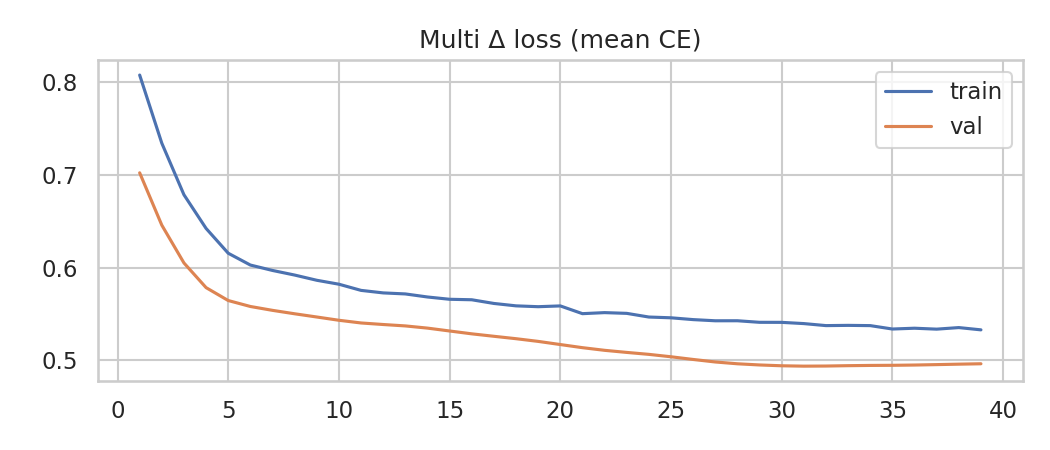

**attn_mean_val.png**

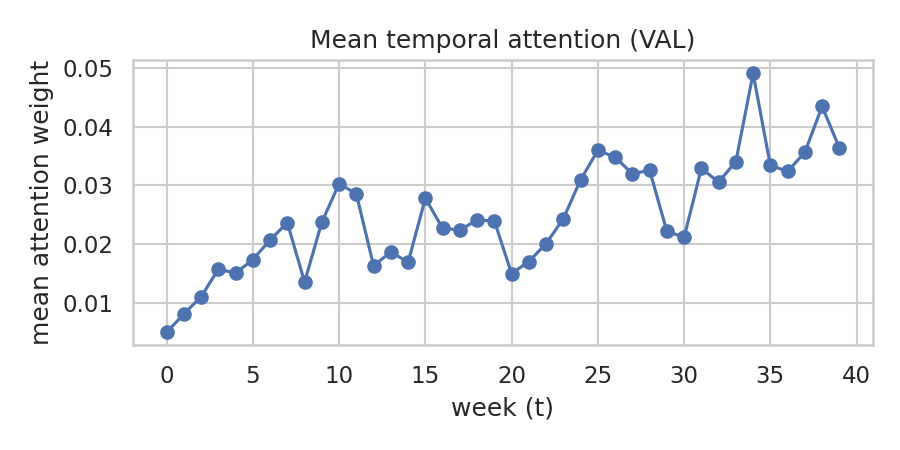

**attn_by_dPHQ_val.png**

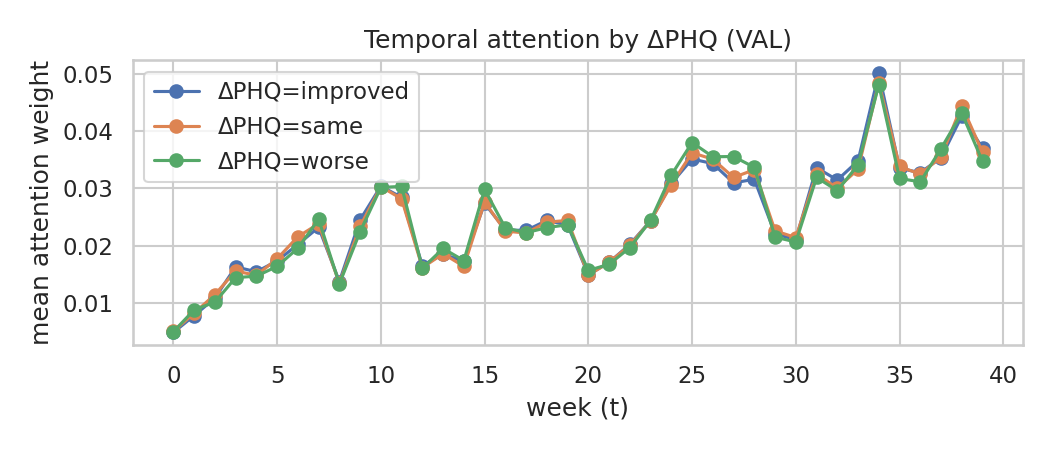

**attn_by_y0PHQ_val.png**

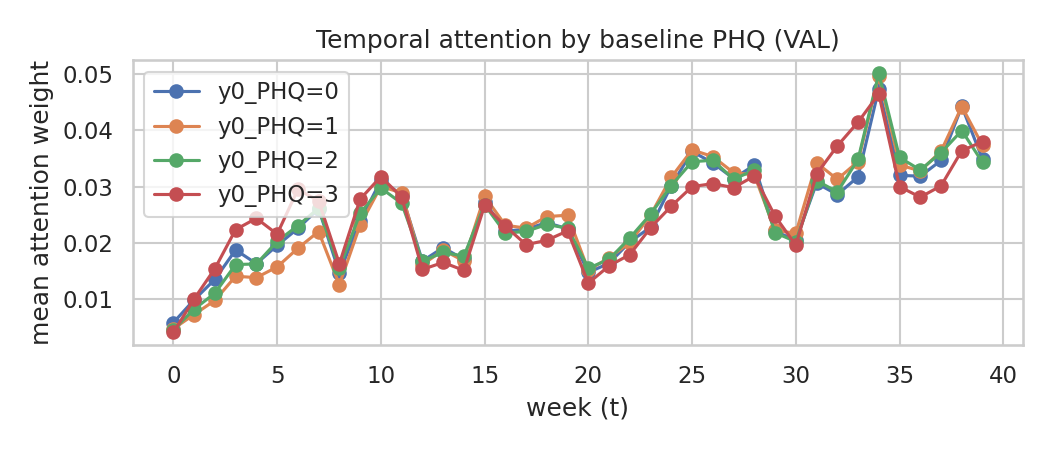

**ch_attn_overall_val.png**

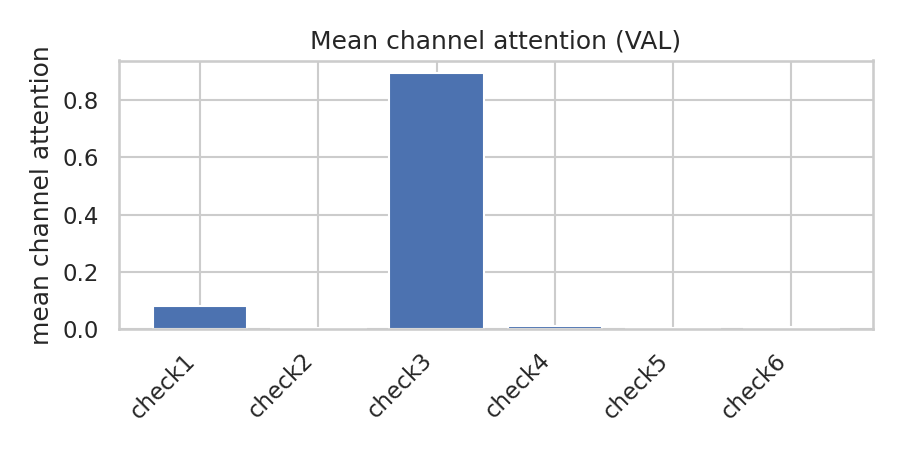

**ch_attn_by_y0PHQ_val.png**

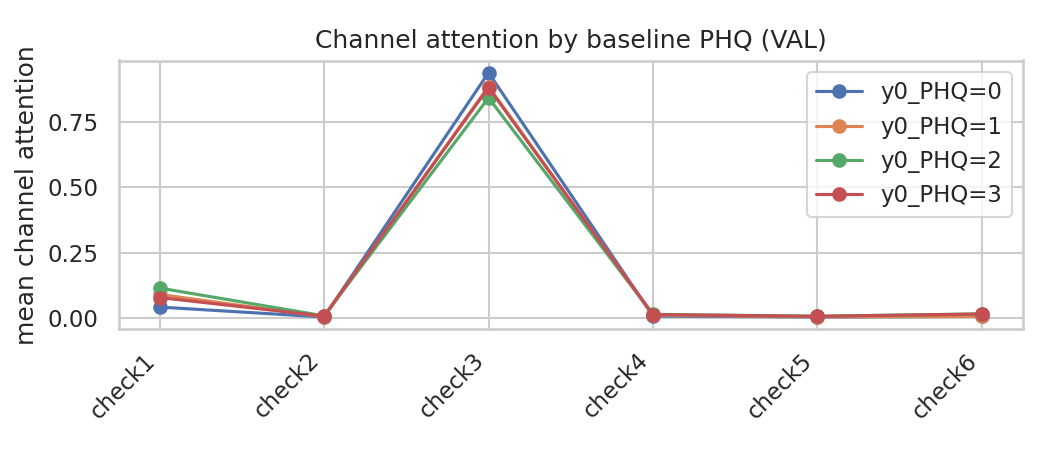

**ch_attn_by_dPHQ_val.png**

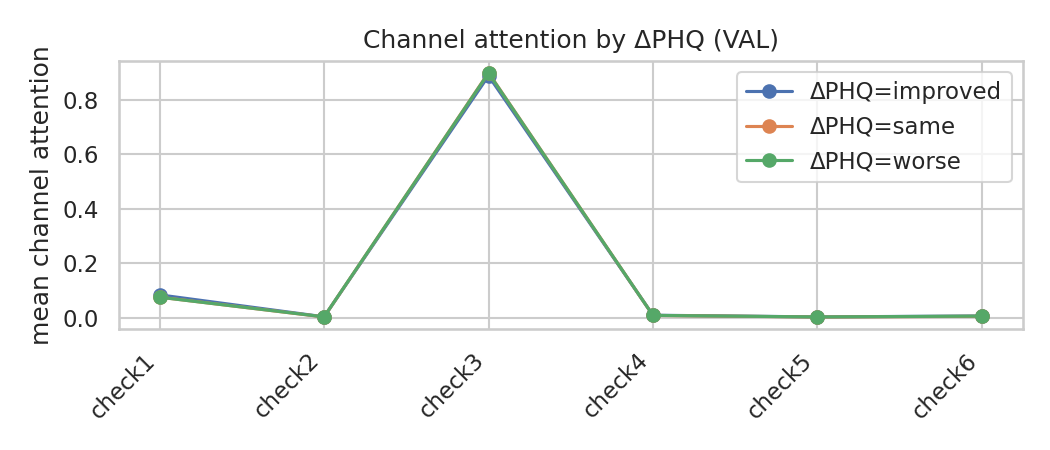

**service_diff_improved_vs_non_top5_val.png**

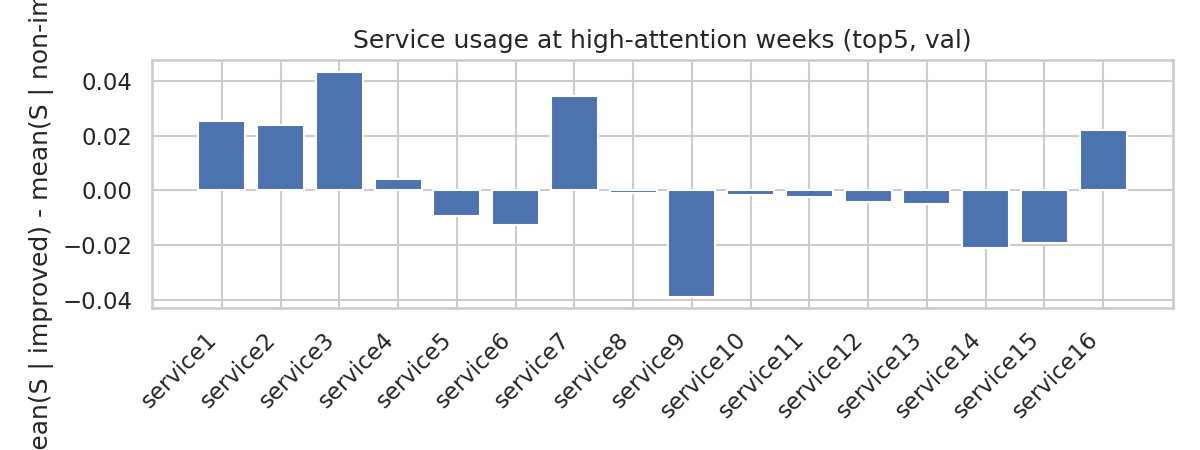

**service_OR_seq_top20_val.png**

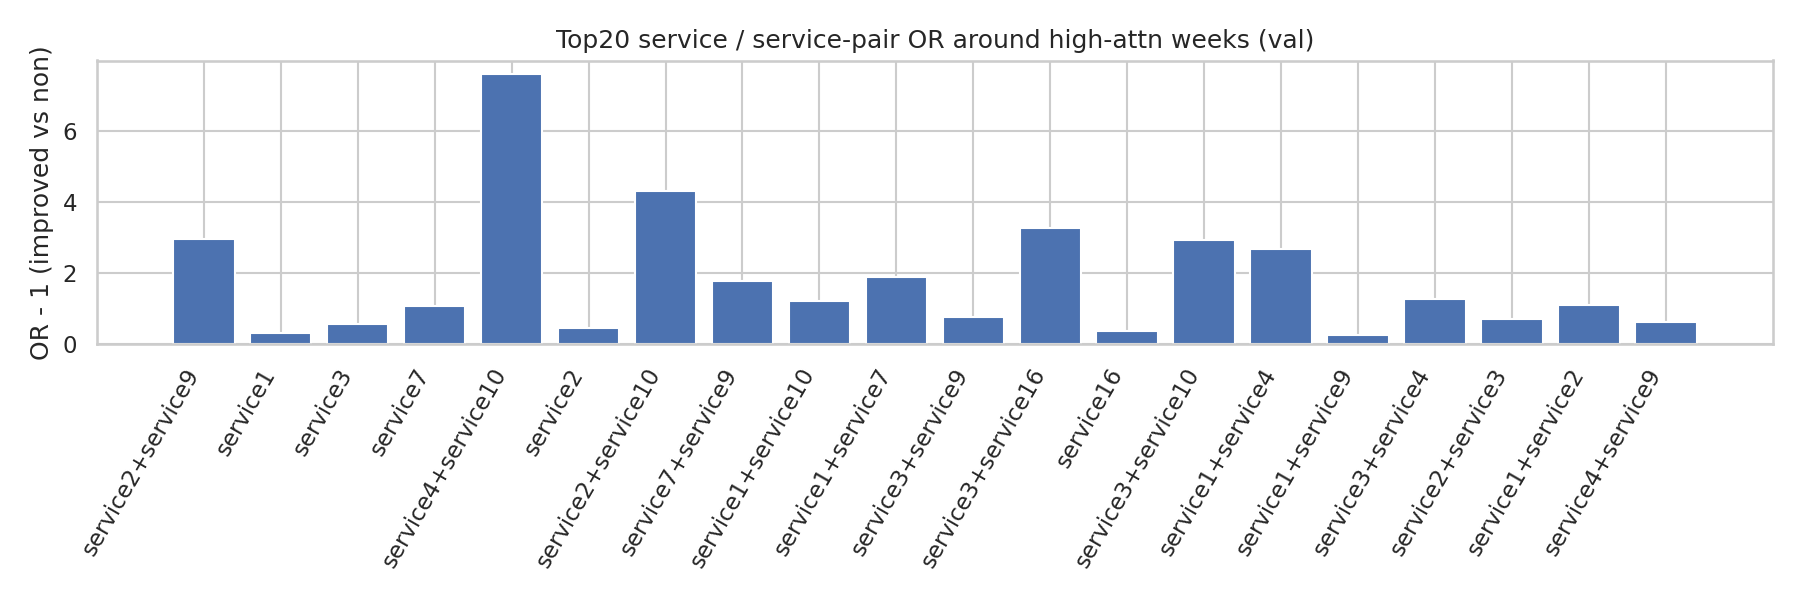

## 📄 Key tables (head)

**service_usage_overall_train.csv**

,service,prop_used_week,mean_weeks_per_patient,std_weeks_per_patient,prop_patients_any_use
0,service1,0.167125,6.685000,10.729027,0.666250
1,service2,0.084156,3.366250,8.524354,0.353125
2,service3,0.110578,4.423125,10.126652,0.343125
3,service4,0.082344,3.293750,8.758565,0.303125
4,service5,0.030391,1.215625,4.903864,0.193750


**service_top5_features_val.csv**

,pid,improved,dPHQ,y0_PHQ,service_total,service1,service2,service3,service4,service5,...,service7,service8,service9,service10,service11,service12,service13,service14,service15,service16
0,7647,0,1,0,200.0,0.2,0.2,0.0,0.6,0.0,...,0.2,0.8,0.4,0.6,0.0,0.0,0.0,0.2,0.8,1.0
1,24917,1,0,2,84.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2008,0,1,1,78.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,24728,0,1,1,80.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,21878,1,0,1,80.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


...

,dPHQ_pred,0,1
0,0,0.041885,0.958115
1,1,0.055556,0.944444
2,2,0.034483,0.965517


**xtab_pred_PHQ_Loneliness.csv**

,dPHQ_pred,0,1,2
0,0,0.005236,0.895288,0.099476
1,1,0.005556,0.866667,0.127778
2,2,0.000000,0.965517,0.034483


## 🧾 interactions_delta.json (prob corr only)

{'PHQw_P4w': -0.04026616104583225,
 'PHQw_Lonw': -0.0213457879232147,
 'PHQi_P4i': 0.035089974590498084,
 'PHQi_Loni': -0.09300337465086343}

In [52]:
import os, json
import pandas as pd
from IPython.display import display, Image, Markdown

import importlib
import approach3

importlib.reload(approach3) 

# ===== (1) 경로/설정 =====
RAW1 = "data/raw_data1.csv"
RAW2 = "data/raw_data2.csv"
T = 40
OUT = "figs_phq_multi_attn"
os.makedirs(OUT, exist_ok=True)

TRAIN = True

# ===== (2) Dataset build =====
batch = approach3.build_dataset(RAW1, RAW2, T=T, outdir=OUT, seed=42)

# 서비스 기본 통계(모델 입력에는 안 들어가지만 batch에 존재)
approach3.service_basic_stats(batch, outdir=OUT, split="train")
approach3.service_stats_by_y0_and_delta_phq(batch, outdir=OUT, split="train")

# ===== (3) Train or Load =====
if TRAIN:
    model, info = approach3.train_model(
        batch,
        outdir=OUT,
        epochs=300,
        lr=1e-3,
        lambda_c=0.0,
        seed=42,
    )
    approach3.save_model(
        OUT,
        model,
        extra={
            "best_ep": info["best_ep"],
            "best_val": info["best_val"],
            "metrics_phq": info["metrics_phq"],
            "metrics_p4": info["metrics_p4"],
            "metrics_lon": info["metrics_lon"],
        },
        filename="phq_multi_seq.ckpt",
    )
else:
    device = batch.C.device
    model = approach3.load_model(OUT, device, filename="phq_multi_seq.ckpt")
    info = {"best_ep": None, "best_val": None}

# ===== (4) Plot / Analysis =====
approach3.plot_attn_by_delta_phq(batch, model, outdir=OUT, split="val")
approach3.plot_attn_by_y0_phq(batch, model, outdir=OUT, split="val")

approach3.plot_ch_attn_overall(batch, model, outdir=OUT, split="val")
approach3.plot_ch_attn_by_y0_phq(batch, model, outdir=OUT, split="val")
approach3.plot_ch_attn_by_delta_phq(batch, model, outdir=OUT, split="val")

approach3.analyze_services_by_attention(batch, model, outdir=OUT, split="val", topk=5)
approach3.run_service_explanation_pipeline(batch, model, OUT, split="val", topk=5)
approach3.analyze_service_seq_and_pairs(
    batch, model, outdir=OUT, split="val",
    topk_attn=5, window=1, min_support_pair=5
)
approach3.analyze_service_seq_with_high_attention(
    batch, model, OUT, split="val", attn_quantile=0.8, min_support_pair=5
)

# OR 요약 테이블 생성
try:
    from pathlib import Path
    or_seq_csv = str(Path(OUT) / "service_OR_seq_val.csv")
    out_pair_csv = str(Path(OUT) / "service_pair_OR_summary_val.csv")
    df_pairs = approach3.build_pair_seq_or_table(or_seq_csv=or_seq_csv, out_csv=out_pair_csv)
except Exception as e:
    df_pairs = None
    print("[WARN] build_pair_seq_or_table failed:", e)

# interaction 분석
approach3.run_full_interaction_analysis(RAW2, batch, model, OUT)

# ===== (5) 결과 표시 =====
display(Markdown("## ✅ Training summary"))
if TRAIN:
    display(pd.DataFrame({
        "best_ep":[info.get("best_ep")],
        "best_val":[info.get("best_val")],
        "PHQ_acc":[(info.get("metrics_phq") or {}).get("acc")],
        "PHQ_f1":[(info.get("metrics_phq") or {}).get("f1")],
        "P4_acc":[(info.get("metrics_p4") or {}).get("acc")],
        "P4_f1":[(info.get("metrics_p4") or {}).get("f1")],
        "Lon_acc":[(info.get("metrics_lon") or {}).get("acc")],
        "Lon_f1":[(info.get("metrics_lon") or {}).get("f1")],
    }))
else:
    display(Markdown("Loaded model from ckpt."))

display(Markdown("## 📈 Key plots"))
plot_files = [
    "learning_multi.png",
    "attn_mean_val.png",
    "attn_by_dPHQ_val.png",
    "attn_by_y0PHQ_val.png",
    "ch_attn_overall_val.png",
    "ch_attn_by_y0PHQ_val.png",
    "ch_attn_by_dPHQ_val.png",
    "service_diff_improved_vs_non_top5_val.png",
    "service_OR_seq_top20_val.png",
]
for fn in plot_files:
    path = os.path.join(OUT, fn)
    if os.path.exists(path):
        display(Markdown(f"**{fn}**"))
        display(Image(filename=path))
    else:
        print("[MISS]", fn)

display(Markdown("## 📄 Key tables (head)"))
csv_files = [
    "service_usage_overall_train.csv",
    "service_top5_features_val.csv",
    "service_OR_seq_val.csv",
    "service_OR_seq_highattn_val.csv",
    "service_pair_OR_summary_val.csv",
    "xtab_true_PHQ_P4.csv",
    "xtab_true_PHQ_Loneliness.csv",
    "xtab_pred_PHQ_P4.csv",
    "xtab_pred_PHQ_Loneliness.csv",
]
for fn in csv_files:
    path = os.path.join(OUT, fn)
    if os.path.exists(path):
        display(Markdown(f"**{fn}**"))
        display(pd.read_csv(path).head())
    else:
        print("[MISS]", fn)

json_path = os.path.join(OUT, "interactions_delta.json")
if os.path.exists(json_path):
    display(Markdown("## 🧾 interactions_delta.json (prob corr only)"))
    with open(json_path, "r", encoding="utf-8") as f:
        js = json.load(f)
    display(js.get("prob_corr", {}))


| Task         | Accuracy | Precision (Macro) | Recall (Macro) | F1-score (Macro) | N   |
| ------------ | -------- | ----------------- | -------------- | ---------------- | --- |
| PHQ-9 Δ      | 0.667    | 0.605             | 0.570          | 0.576            | 400 |
| P4 Δ         | 0.965    | 0.621             | 0.665          | 0.642            | 400 |
| Loneliness Δ | 0.782    | 0.630             | 0.626          | 0.537            | 400 |


### 📊 PHQ-9 Δ Validation Performance (n = 400)

| Metric / Class | Overall   | Improved (0) | Unchanged (1) | Worsened (2) |
| -------------- | --------- | ------------ | ------------- | ------------ |
| Accuracy       | **0.667** | –            | –             | –            |
| Precision      | **0.605** | 0.738        | 0.628         | 0.448        |
| Recall         | **0.570** | 0.820        | 0.649         | 0.241        |
| F1-score       | **0.576** | –            | –             | –            |

이 모델은 ‘개선(improved)’ 상태를 식별하는 데는 충분히 신뢰 가능하며,\
해당 조건 하에서 attention은 ‘개선과 연관된 신호 후보’를 제시한다.

In [42]:
n_patients = batch.C.shape[0]
T = batch.C.shape[1]

print("N patients:", n_patients)
print("Sequence length (T):", T)

N patients: 2000
Sequence length (T): 40


In [43]:
def y0_dist(y, name):
    vc = (
        pd.Series(y.cpu().numpy())
        .value_counts(normalize=True)
        .sort_index()
        .reset_index()
    )
    vc.columns = ["severity", "proportion"]
    vc["outcome"] = name
    return vc

y0_phq_dist = y0_dist(batch.y0_phq, "PHQ-9")
y0_p4_dist  = y0_dist(batch.y0_p4,  "P4")
y0_lon_dist = y0_dist(batch.y0_lon, "Loneliness")

baseline_dist = pd.concat([y0_phq_dist, y0_p4_dist, y0_lon_dist])
display(baseline_dist)


,severity,proportion,outcome
0,0,0.2440,PHQ-9
1,1,0.6105,PHQ-9
2,2,0.1160,PHQ-9
3,3,0.0295,PHQ-9
0,0,0.9510,P4
1,1,0.0100,P4
2,2,0.0390,P4
0,0,0.1160,Loneliness
1,1,0.8840,Loneliness


/tmp/ipykernel_148684/802733468.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_148684/802733468.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_148684/802733468.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


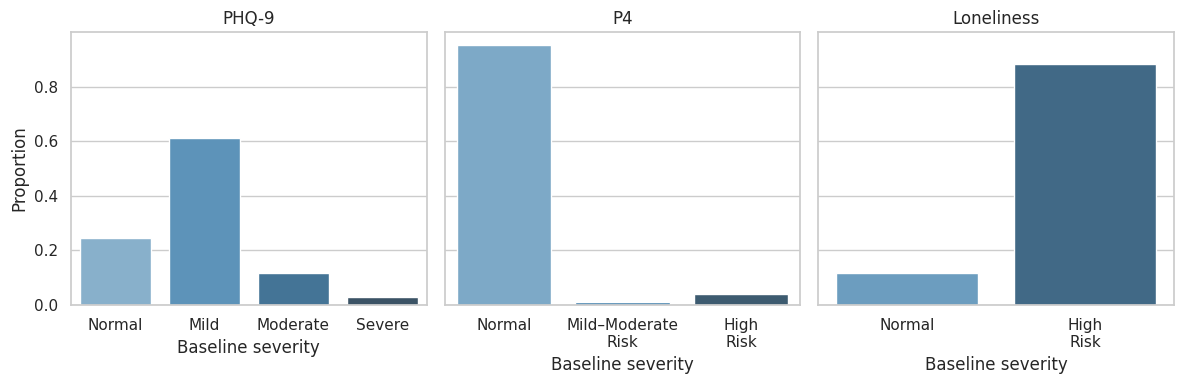

In [44]:
severity_labels = {
    "PHQ-9": {
        0: "Normal",
        1: "Mild",
        2: "Moderate",
        3: "Severe",
    },
    "P4": {
        0: "Normal",
        1: "Mild–Moderate\nRisk",
        2: "High\nRisk",
    },
    "Loneliness": {
        0: "Normal",
        1: "High\nRisk",
    }
}


sns.set_theme(style="whitegrid")

outcomes = baseline_dist["outcome"].unique()
n_out = len(outcomes)

fig, axes = plt.subplots(1, n_out, figsize=(4*n_out, 4), sharey=True)

if n_out == 1:
    axes = [axes]

for ax, outcome in zip(axes, outcomes):
    data = baseline_dist[baseline_dist["outcome"] == outcome]
    
    sns.barplot(
        data=data,
        x="severity",
        y="proportion",
        ax=ax,
        palette="Blues_d"
    )
    
    ax.set_title(outcome)
    ax.set_xlabel("Baseline severity")
    ax.set_ylabel("Proportion")

    sev_map = severity_labels[outcome]
    ticks = sorted(sev_map.keys())
    labels = [sev_map[t] for t in ticks]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

plt.tight_layout()
plt.show()


In [45]:
def delta_dist(dY, name):
    vc = (
        pd.Series(dY.cpu().numpy())
        .value_counts(normalize=True)
        .sort_index()
        .reset_index()
    )
    vc.columns = ["delta", "proportion"]
    vc["outcome"] = name
    return vc

delta_phq = delta_dist(batch.dY_phq, "PHQ-9")
delta_p4  = delta_dist(batch.dY_p4,  "P4")
delta_lon = delta_dist(batch.dY_lon, "Loneliness")

delta_dist_df = pd.concat([delta_phq, delta_p4, delta_lon])
display(delta_dist_df)


,delta,proportion,outcome
0,0,0.4295,PHQ-9
1,1,0.4345,PHQ-9
2,2,0.1360,PHQ-9
0,0,0.0440,P4
1,1,0.9385,P4
2,2,0.0175,P4
0,0,0.1685,Loneliness
1,1,0.7695,Loneliness
2,2,0.0620,Loneliness


/tmp/ipykernel_148684/3483606480.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_148684/3483606480.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_148684/3483606480.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


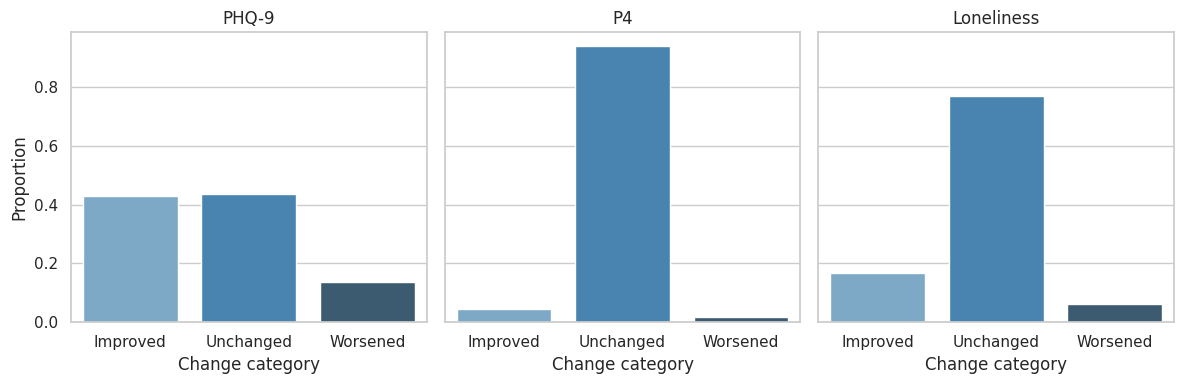

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

outcomes = delta_dist_df["outcome"].unique()
n_out = len(outcomes)

fig, axes = plt.subplots(1, n_out, figsize=(4*n_out, 4), sharey=True)

if n_out == 1:
    axes = [axes]

# 논문용 label 매핑
delta_labels = {
    0: "Improved",
    1: "Unchanged",
    2: "Worsened"
}

for ax, outcome in zip(axes, outcomes):
    data = delta_dist_df[delta_dist_df["outcome"] == outcome]
    sns.barplot(
        data=data,
        x="delta",
        y="proportion",
        ax=ax,
        palette="Blues_d"
    )
    ax.set_title(outcome)
    ax.set_xlabel("Change category")
    ax.set_ylabel("Proportion")

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([
        "Improved",
        "Unchanged",
        "Worsened"
    ])

plt.tight_layout()
plt.show()



In [47]:
check_names = batch.stats["check_basenames"]
levels = batch.levels.cpu().numpy()
is_bin = batch.is_bin.cpu().numpy()

check_table = pd.DataFrame({
    "check": check_names,
    "levels": levels,
    "binary": is_bin,
})
display(check_table)


,check,levels,binary
0,check1,3,False
1,check2,2,True
2,check3,2,True
3,check4,2,True
4,check5,3,False
5,check6,4,False


### Check3에 대한 유의미한 파생 feature _ phq9 improved vs else

In [53]:
from check3_improved_feature_discovery import (
    DiscoverConfig, GroupConfig, ValConfig, discover_check3_characteristics
)
# outdir 원하는 경로로
cfg = DiscoverConfig(
    outdir="./out_check3_discovery",
    group=GroupConfig(
        split="val",              # "train"도 가능
        target_channel="check3",
        improved_label=0,         
        smooth=3,
        n_boot=2000,
        n_perm=5000,
        seed=0,
        fdr_q_max=0.10,
        abs_cohens_d_min=0.20,
    ),
    val=ValConfig(
        split="val",
        target_channel="check3",
        improved_label=0,
        smooth=3,
        n_boot_auc=3000,
        half_width=1,
        n_random=50,
        n_perm_window=8000,
        window_mode="set_patient_mean",
        ablation_modes=["permute_time", "set_patient_mean", "set_global_mode"],
        seed=0,
    ),
    marker_feature=None,  # None이면 자동으로 best candidate를 marker로 선택
)

out = discover_check3_characteristics(batch, model, cfg)
out["paths"]


{'features_csv': './out_check3_discovery/per_patient_features_val.csv',
 'tests_csv': './out_check3_discovery/stats_tests_val.csv',
 'candidates_csv': './out_check3_discovery/candidate_findings_val.csv',
 'top_findings_csv': './out_check3_discovery/top_findings_val.csv',
 'final_summary_csv': './out_check3_discovery/final_summary_val.csv',
 'v1_auc_csv': './out_check3_discovery/v1_auc_val.csv',
 'v4_window_csv': './out_check3_discovery/v4_window_faithfulness_val.csv',
 'v3_ablation_csv': './out_check3_discovery/v3_model_ablation_val.csv'}

In [54]:
paths = out["paths"]

df_tests = pd.read_csv(paths["tests_csv"])
df_cand  = pd.read_csv(paths["candidates_csv"])
df_top   = pd.read_csv(paths["top_findings_csv"])
df_final = pd.read_csv(paths["final_summary_csv"])

display(df_final)
display(df_top.head(10))
display(df_cand.head(20))


,chosen_marker_feature,marker_auc,marker_auc_ci95_lo,marker_auc_ci95_hi,v4_perm_p,v4_mean_diff(targeted-random),baseline_macro_f1
0,ch3a_dpeak_val,0.761003,0.713288,0.807071,0.000125,0.002165,0.345691


,rank,feature,diff_mean(improved-else),cohens_d,cliffs_delta,boot_diff_mean,ci95_lo,ci95_hi,perm_p,n_improved,n_else,abs_cohens_d,fdr_q
0,1,ch3a_dpeak_val,0.007863,0.676633,0.522006,0.007867,0.005625,0.010121,0.000200,172,228,0.676633,0.002999
1,2,margin_min,-0.066526,-0.501199,-0.415494,-0.066466,-0.091725,-0.040575,0.000200,172,228,0.501199,0.002999
2,3,dom_ratio_max,-9.458828,-0.396850,-0.228529,-9.458482,-14.146388,-5.036993,0.000600,172,228,0.396850,0.003599
3,4,dom_ratio_mean,-9.142171,-0.392065,-0.206854,-9.135770,-13.622106,-4.948957,0.000600,172,228,0.392065,0.003599
4,5,ch3a_vol,0.001615,0.354028,0.429417,0.001613,0.000786,0.002442,0.000400,172,228,0.354028,0.003599
5,6,corr_c3_ch3a,-0.108849,-0.306450,-0.175949,-0.107308,-0.175335,-0.035768,0.001600,172,228,0.306450,0.007998
6,7,corr_attn_c3,-0.080274,-0.245818,-0.161108,-0.079058,-0.144143,-0.012585,0.016597,172,228,0.245818,0.071129
7,8,aw_c3_sum,-0.197177,-0.233846,-0.109700,-0.197168,-0.366283,-0.028065,0.020996,172,228,0.233846,0.078734
8,9,c3_mean,-0.187300,-0.227312,-0.092666,-0.187608,-0.351556,-0.025641,0.027195,172,228,0.227312,0.081584
9,10,corr_attn_ch3a,0.092818,0.226941,0.131222,0.092482,0.011912,0.172257,0.026595,172,228,0.226941,0.081584


,feature,diff_mean(improved-else),cohens_d,cliffs_delta,boot_diff_mean,ci95_lo,ci95_hi,perm_p,n_improved,n_else,abs_cohens_d,fdr_q
0,ch3a_dpeak_val,0.007863,0.676633,0.522006,0.007867,0.005625,0.010121,0.000200,172,228,0.676633,0.002999
1,margin_min,-0.066526,-0.501199,-0.415494,-0.066466,-0.091725,-0.040575,0.000200,172,228,0.501199,0.002999
2,ch3a_vol,0.001615,0.354028,0.429417,0.001613,0.000786,0.002442,0.000400,172,228,0.354028,0.003599
3,dom_ratio_max,-9.458828,-0.396850,-0.228529,-9.458482,-14.146388,-5.036993,0.000600,172,228,0.396850,0.003599
4,dom_ratio_mean,-9.142171,-0.392065,-0.206854,-9.135770,-13.622106,-4.948957,0.000600,172,228,0.392065,0.003599
5,corr_c3_ch3a,-0.108849,-0.306450,-0.175949,-0.107308,-0.175335,-0.035768,0.001600,172,228,0.306450,0.007998
6,corr_attn_c3,-0.080274,-0.245818,-0.161108,-0.079058,-0.144143,-0.012585,0.016597,172,228,0.245818,0.071129
7,aw_c3_sum,-0.197177,-0.233846,-0.109700,-0.197168,-0.366283,-0.028065,0.020996,172,228,0.233846,0.078734
8,corr_attn_ch3a,0.092818,0.226941,0.131222,0.092482,0.011912,0.172257,0.026595,172,228,0.226941,0.081584
9,c3_mean,-0.187300,-0.227312,-0.092666,-0.187608,-0.351556,-0.025641,0.027195,172,228,0.227312,0.081584


In [55]:
df_feat = out["df_features"]
cols = ["pid", "dPHQ", "is_improved", "ch3a_dpeak_val", "margin_min", "dom_ratio_mean", "dom_ratio_max"]
display(df_feat[cols].head(10))

,pid,dPHQ,is_improved,ch3a_dpeak_val,margin_min,dom_ratio_mean,dom_ratio_max
0,7647,1,0,0.015640,0.850190,92.336716,104.735336
1,24917,0,1,0.033168,0.364585,11.840233,16.666477
2,2008,1,0,0.020602,0.689992,32.545101,46.289745
3,24728,1,0,0.028171,0.755140,66.968918,83.318497
4,21878,0,1,0.024450,0.757990,55.749939,72.108864
5,2170,1,0,0.033228,0.718476,62.752724,78.854004
6,23998,1,0,0.040704,0.656880,35.724049,45.944397
7,24742,1,0,0.015597,0.716688,32.369774,39.824955
8,27368,1,0,0.016350,0.843785,100.068680,111.621140
9,1191,0,1,0.030861,0.760631,78.524696,87.837990


In [56]:
df_feat["is_improved"].value_counts()


is_improved
0    228
1    172
Name: count, dtype: int64

### A. “개선 여부를 얼마나 잘 구분하는가?” (분리 성능 & 안정성)

| 지표명                         | 의미 (자연어 설명)                                          | 계산 방식 / 수식                        | 판단 기준         | 이 기준을 쓰는 이유                                 |
| --------------------------- | ---------------------------------------------------- | --------------------------------- | ------------- | ------------------------------------------- |
| **marker_auc**              | 해당 feature 하나만으로도 *개선된 환자*와 *그렇지 않은 환자*를 얼마나 잘 구분하는지 | (\text{AUC} = P(s(x^+) > s(x^-))) | **AUC > 0.7** | 0.5는 무작위 수준이므로, 이를 명확히 상회해야 “구분 정보가 있다”고 판단 |
| **marker_auc_ci95_lo / hi** | 위 구분 성능이 데이터 변동에도 유지되는지                              | Bootstrap으로 AUC 반복 계산 후 95% 분위수   | **하한 > 0.5**  | 특정 표본에 우연히 잘 맞은 결과가 아님을 보장하기 위함             |


### B. “두 집단 간 차이가 실제로 존재하는가?” (통계적 유의성)

| 지표명                           | 의미 (자연어 설명)                           | 계산 방식 / 수식                       | 판단 기준        | 이 기준을 쓰는 이유                                 |
| ----------------------------- | ------------------------------------- | -------------------------------- | ------------ | ------------------------------------------- |
| **diff_mean (improved−else)** | 개선 집단과 비개선 집단 간 feature 평균 차이의 방향과 크기 | (\bar{x}*{imp} - \bar{x}*{else}) | 방향성 확인용      | 어떤 집단에서 더 큰지 직관적으로 설명 가능                    |
| **boot_diff_mean**            | 평균 차이가 표본 재추출에도 유지되는지                 | Bootstrap 평균 차이                  | CI와 함께 해석    | 평균 차이가 우연이 아님을 확인                           |
| **ci95_lo / ci95_hi**         | 평균 차이의 신뢰 구간                          | Bootstrap 95% CI                 | **0 미포함**    | 평균 차이가 0이 아니라는 보수적 증거                       |
| **perm_p**                    | 두 집단 차이가 우연히 생길 확률                    | Permutation test                 | **p < 0.05** | 분포 가정이 필요 없는 비모수 검정 → attention feature에 적합 |
| **fdr_q**                     | 여러 feature를 동시에 검정했을 때의 보정 p값         | Benjamini–Hochberg               | **q < 0.1**  | 다중 비교로 인한 거짓 양성 억제                          |


### C. “차이가 얼마나 큰가?” (효과 크기)

| 지표명              | 의미 (자연어 설명)                  | 계산 방식 / 수식                  | 판단 기준         | 이 기준을 쓰는 이유              |              |                          |
| ---------------- | ---------------------------- | --------------------------- | ------------- | ------------------------ | ------------ | ------------------------ |
| **cohens_d**     | 두 집단 평균 차이를 표준화한 효과 크기       | (\frac{\mu_1 - \mu_2}{s_p}) | **|d| ≥ 0.5** | 단순 유의성(p)보다 “실질적 차이”를 판단 |              |                          |
| **abs_cohens_d** | 효과 크기의 절댓값                   | (                           | d             | )                        | **≥ 0.5**    | 방향과 무관하게 차이의 크기에 집중      |
| **cliffs_delta** | 임의의 improved 샘플이 else보다 클 확률 | (P(x>y)-P(x<y))             | (             | \delta                   | ≥ 0.33) (중간) | 분포 비대칭·이상치에 강건한 효과 크기 지표 |


### D. “모델이 실제로 이 feature를 쓰고 있는가?” (모델 활용성)

| 지표명                                | 의미 (자연어 설명)                                 | 계산 방식 / 개념                                      | 판단 기준                           | 이 기준을 쓰는 이유               |
| ---------------------------------- | ------------------------------------------- | ----------------------------------------------- | ------------------------------- | ------------------------- |
| **v4_mean_diff (targeted−random)** | attention 급변 시점 제거가 무작위 제거보다 예측을 더 망가뜨리는 정도 | Target window 제거 vs Random window 제거 후 logit 차이 | **Targeted drop > Random drop** | 모델이 특정 시점 정보를 실제로 사용함을 확인 |
| **v4_perm_p**                      | 위 차이가 우연일 확률                                | Sign-flip permutation test                      | **p < 0.05**                    | “그럴듯해 보임”이 아닌 통계적 검증      |


### E. “모델 전체 성능 맥락” (참고 지표)

| 지표명                     | 의미 (자연어 설명)                                  | 계산 방식      | 사용 방식   | 주의점                                    |
| ----------------------- | -------------------------------------------- | ---------- | ------- | -------------------------------------- |
| **baseline_macro_f1**   | 3단계 변화(improved/unchanged/worsened) 전체 평균 성능 | 클래스별 F1 평균 | **참고용** | 본 연구의 1차 판단 기준 아님 (이진 improved 분석이 목적) |
| **n_improved / n_else** | 각 집단 표본 수                                    | Count      | 해석 보조   | 표본 불균형 여부 명시                           |


이 feature는 (1) 개선 여부를 구분할 수 있고,\
(2) 그 성능이 우연이 아니며,\
(3) 집단 간 차이가 실질적으로 크고,\
(4) 모델이 실제로 해당 정보를 사용하고 있음을\
여러 지표로 교차 검증하였다.

In [ ]:
from check3_improved_feature_discovery import extract_tensors
from attn_check3_timestep_analysis import analyze_check3_timestep, TimeStepCfg
cfg = TimeStepCfg(
    split="val",
    target_channel="check3",
    improved_label=0,
    smooth=3,
    save_npz=True
)

out_ts = analyze_check3_timestep(
    batch=batch,
    model=model,
    outdir="OUT_TIMESTEP_CHECK3",
    extract_attn_tensors_fn=extract_tensors,  
    cfg=cfg
)

out_ts["t_max"], out_ts["paths"]


(1,
 {'attn_csv': 'OUT_TIMESTEP_CHECK3/timestep_attn_val.csv',
  'slope_csv': 'OUT_TIMESTEP_CHECK3/timestep_slope_val.csv',
  'plot_slope': 'OUT_TIMESTEP_CHECK3/plot_slope_diff_val.png',
  'plot_attn': 'OUT_TIMESTEP_CHECK3/plot_attn_mean_val.png',
  'npz': 'OUT_TIMESTEP_CHECK3/per_patient_check3_series_val.npz'})

In [64]:
import matplotlib.pyplot as plt

# 주피터에서 플롯 안 뜰 때 1순위 해결
%matplotlib inline


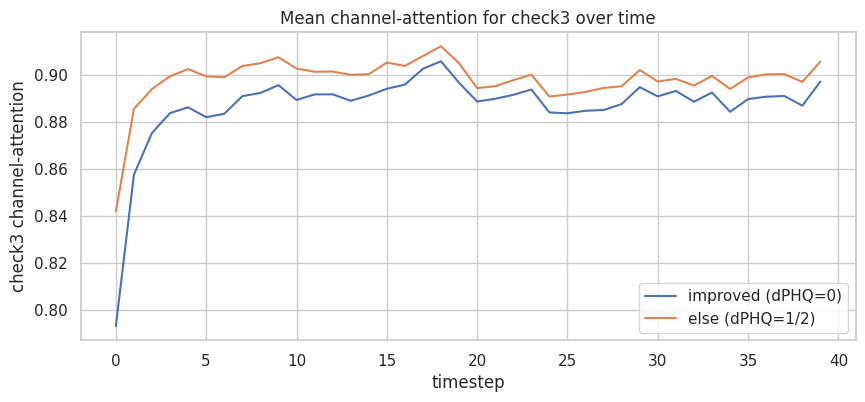

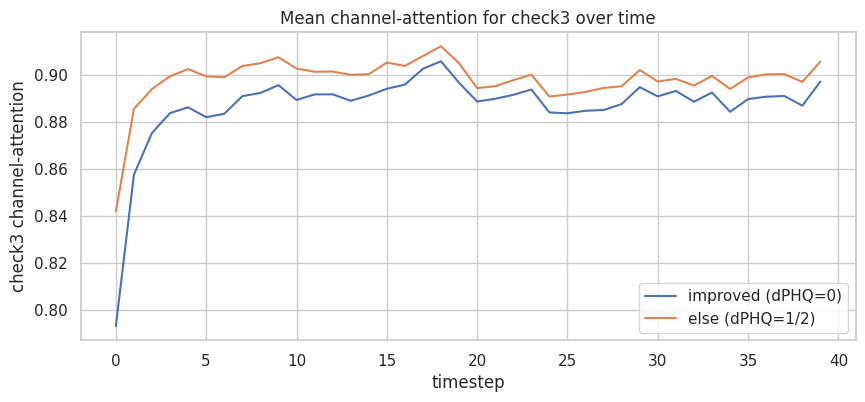

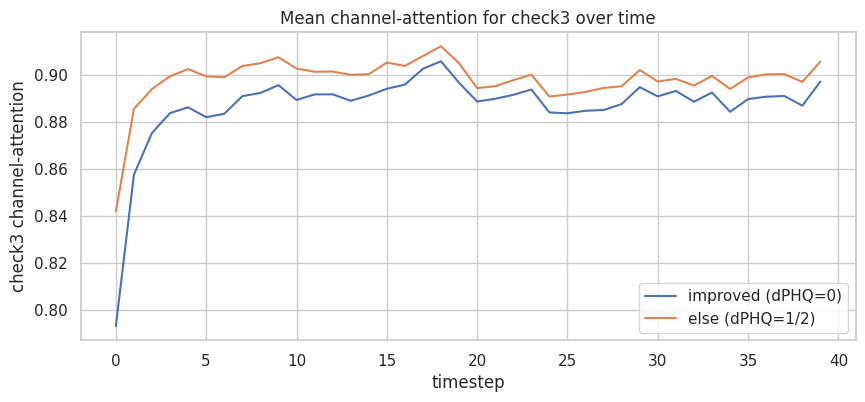

In [65]:
data = extract_tensors(batch, model, split="val")
ch_alpha = data["ch_alpha"]      # (B,T,C)
dPHQ = data["dPHQ"]              # (B,)
check_names = data["check_names"]

# check3 index
def find_channel_index(check_names, target="check3"):
    target_l = target.lower().strip()
    for i, n in enumerate(check_names):
        if str(n).lower().strip() == target_l:
            return i
    for i, n in enumerate(check_names):
        if target_l in str(n).lower().strip():
            return i
    raise ValueError("check3 not found")

ch3_idx = find_channel_index(check_names, "check3")

improved = (dPHQ == 0)
else_ = ~improved

ch3a = ch_alpha[:, :, ch3_idx]   # (B,T)

m_imp = ch3a[improved].mean(axis=0)
m_else = ch3a[else_].mean(axis=0)

plt.figure(figsize=(10,4))
plt.plot(m_imp, label="improved (dPHQ=0)")
plt.plot(m_else, label="else (dPHQ=1/2)")
plt.title("Mean channel-attention for check3 over time")
plt.xlabel("timestep")
plt.ylabel("check3 channel-attention")
plt.legend()
plt.show()


Largest slope-gap segment: 0 -> 1
mean slope improved: 0.06454431
mean slope else    : 0.04363314
abs gap            : 0.020911172


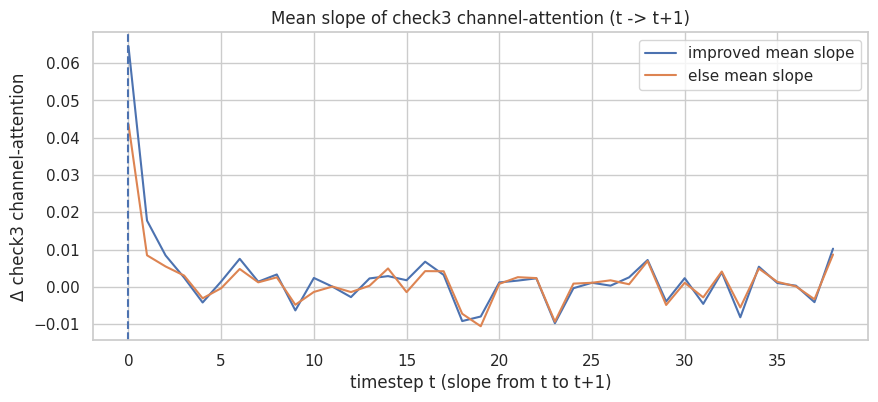

In [66]:
dch3a = np.diff(ch3a, axis=1)  # (B,T-1)

m_slope_imp = dch3a[improved].mean(axis=0)
m_slope_else = dch3a[else_].mean(axis=0)

gap = np.abs(m_slope_imp - m_slope_else)
t_max = int(np.argmax(gap))   # 이때는 "t -> t+1" 구간의 t

print("Largest slope-gap segment:", t_max, "->", t_max+1)
print("mean slope improved:", m_slope_imp[t_max])
print("mean slope else    :", m_slope_else[t_max])
print("abs gap            :", gap[t_max])

plt.figure(figsize=(10,4))
plt.plot(m_slope_imp, label="improved mean slope")
plt.plot(m_slope_else, label="else mean slope")
plt.axvline(t_max, linestyle="--")
plt.title("Mean slope of check3 channel-attention (t -> t+1)")
plt.xlabel("timestep t (slope from t to t+1)")
plt.ylabel("Δ check3 channel-attention")
plt.legend()
plt.show()


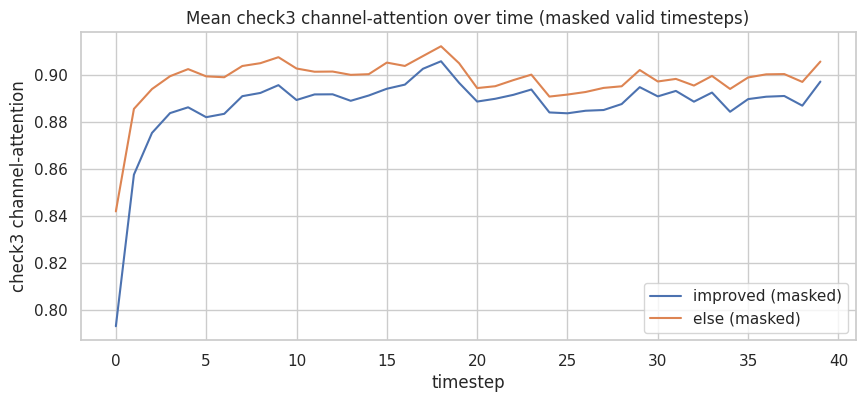

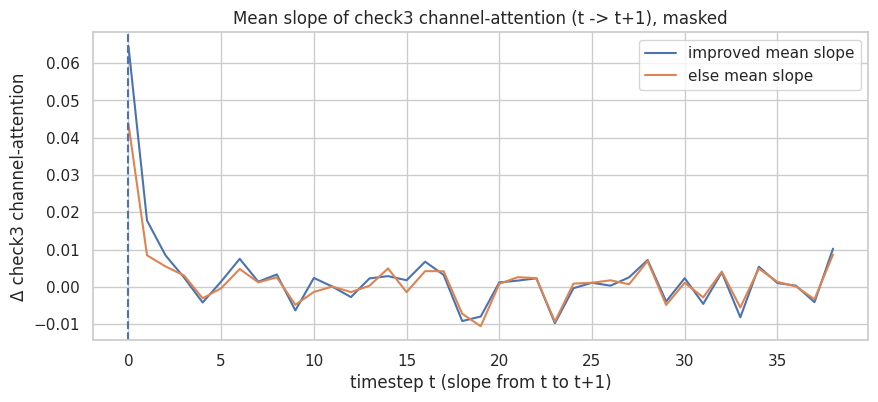

Largest slope-gap segment (masked): 0 -> 1
mean slope improved: 0.06454431
mean slope else    : 0.04363314
abs gap            : 0.020911172


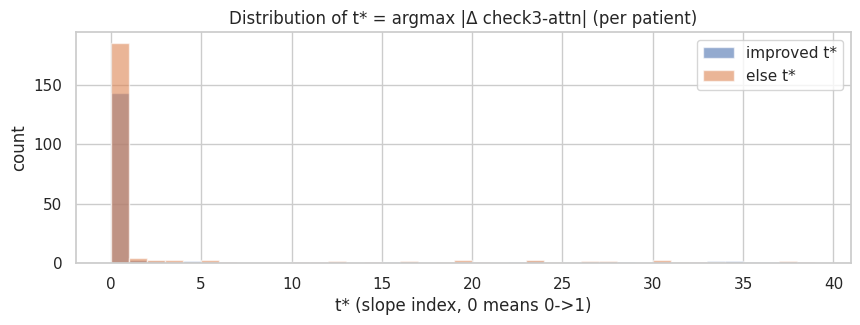

t* most common (improved): 0
t* most common (else):     0


In [67]:
# 1) extract
data = extract_tensors(batch, model, split="val")
ch_alpha = data["ch_alpha"]      # (B,T,C)
dPHQ = data["dPHQ"]              # (B,)
check_names = data["check_names"]

def find_channel_index(check_names, target="check3"):
    target_l = target.lower().strip()
    for i, n in enumerate(check_names):
        if str(n).lower().strip() == target_l:
            return i
    for i, n in enumerate(check_names):
        if target_l in str(n).lower().strip():
            return i
    raise ValueError("check3 not found")

ch3_idx = find_channel_index(check_names, "check3")
ch3a = ch_alpha[:, :, ch3_idx]   # (B,T)

improved = (dPHQ == 0)
else_ = ~improved

B, T = ch3a.shape

# 2) valid mask 만들기 (아래 중 하나로 바꿔줘!)
# (A) 길이 정보가 있다면 (예: batch.lengths[idx])
# lengths = batch.lengths[batch.idx_val]  # (B,)
# valid_mask = np.arange(T)[None, :] < lengths[:, None]  # (B,T)

# (B) padding이 "모든 채널이 0" 이라면 C로 추정 (조심: 실제 0이 가능하면 안됨)
C_val = data["C"].detach().cpu().numpy()  # (B,T,C)
valid_mask = (np.abs(C_val).sum(axis=2) > 0)  # (B,T)

# 3) mask 적용 평균 함수
def masked_mean(x_bt, mask_bt):
    # x_bt: (B,T), mask_bt: (B,T) boolean
    x = x_bt.copy()
    x[~mask_bt] = np.nan
    return np.nanmean(x, axis=0)

m_imp = masked_mean(ch3a[improved], valid_mask[improved])
m_else = masked_mean(ch3a[else_], valid_mask[else_])

# 4) slope도 mask 기반으로 (t->t+1 둘 다 valid인 곳만)
def masked_slope_mean(x_bt, mask_bt):
    # slope at t = x[t+1]-x[t], for t=0..T-2
    x = x_bt.copy()
    x[~mask_bt] = np.nan
    dx = x[:, 1:] - x[:, :-1]
    mask_s = mask_bt[:, 1:] & mask_bt[:, :-1]
    dx[~mask_s] = np.nan
    return np.nanmean(dx, axis=0), dx, mask_s  # mean over B

s_imp, dx_imp, msk_imp_s = masked_slope_mean(ch3a[improved], valid_mask[improved])
s_else, dx_else, msk_else_s = masked_slope_mean(ch3a[else_], valid_mask[else_])

# 5) plot: mean ch3a
plt.figure(figsize=(10,4))
plt.plot(m_imp, label="improved (masked)")
plt.plot(m_else, label="else (masked)")
plt.title("Mean check3 channel-attention over time (masked valid timesteps)")
plt.xlabel("timestep")
plt.ylabel("check3 channel-attention")
plt.legend()
plt.show()

# 6) plot: mean slope
plt.figure(figsize=(10,4))
plt.plot(s_imp, label="improved mean slope")
plt.plot(s_else, label="else mean slope")
plt.axvline(0, linestyle="--")
plt.title("Mean slope of check3 channel-attention (t -> t+1), masked")
plt.xlabel("timestep t (slope from t to t+1)")
plt.ylabel("Δ check3 channel-attention")
plt.legend()
plt.show()

# 7) 가장 gap 큰 구간 다시 계산
gap = np.abs(s_imp - s_else)
t_max = int(np.nanargmax(gap))
print(f"Largest slope-gap segment (masked): {t_max} -> {t_max+1}")
print("mean slope improved:", s_imp[t_max])
print("mean slope else    :", s_else[t_max])
print("abs gap            :", gap[t_max])

# 8) 환자별 t* (최대 |Δ| 위치) 분포 비교
def per_patient_tstar(x_bt, mask_bt):
    x = x_bt.copy()
    x[~mask_bt] = np.nan
    dx = x[:, 1:] - x[:, :-1]
    mask_s = mask_bt[:, 1:] & mask_bt[:, :-1]
    dx[~mask_s] = np.nan
    # |dx|의 argmax (nan은 무시되도록 nanargmax 사용)
    absdx = np.abs(dx)
    tstar = np.nanargmax(absdx, axis=1)  # 0..T-2
    dpeak = np.nanmax(absdx, axis=1)
    return tstar, dpeak

tstar_imp, dpeak_imp = per_patient_tstar(ch3a[improved], valid_mask[improved])
tstar_else, dpeak_else = per_patient_tstar(ch3a[else_], valid_mask[else_])

plt.figure(figsize=(10,3))
plt.hist(tstar_imp, bins=np.arange(T), alpha=0.6, label="improved t*")
plt.hist(tstar_else, bins=np.arange(T), alpha=0.6, label="else t*")
plt.title("Distribution of t* = argmax |Δ check3-attn| (per patient)")
plt.xlabel("t* (slope index, 0 means 0->1)")
plt.ylabel("count")
plt.legend()
plt.show()

print("t* most common (improved):", np.bincount(tstar_imp).argmax())
print("t* most common (else):    ", np.bincount(tstar_else).argmax())


mean c3(t0) improved: 0.3775018
mean c3(t0) else    : 0.25159642


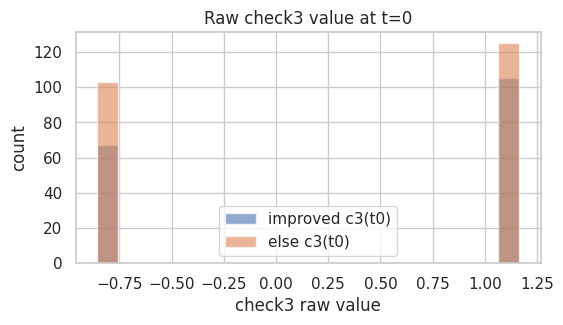

In [68]:
import numpy as np
import matplotlib.pyplot as plt

C_val = data["C"].detach().cpu().numpy()
c3 = C_val[:, :, ch3_idx]  # (B,T) raw check3

c3_t0_imp  = c3[improved, 0]
c3_t0_else = c3[else_, 0]

print("mean c3(t0) improved:", np.mean(c3_t0_imp))
print("mean c3(t0) else    :", np.mean(c3_t0_else))

plt.figure(figsize=(6,3))
plt.hist(c3_t0_imp,  bins=20, alpha=0.6, label="improved c3(t0)")
plt.hist(c3_t0_else, bins=20, alpha=0.6, label="else c3(t0)")
plt.title("Raw check3 value at t=0")
plt.xlabel("check3 raw value")
plt.ylabel("count")
plt.legend()
plt.show()


In [69]:
from sklearn.metrics import roc_auc_score

y_bin = improved.astype(int)
score = c3[:, 0].astype(float)
auc = roc_auc_score(y_bin, score)
print("AUC using only raw check3(t0):", auc)


AUC using only raw check3(t0): 0.531109751121991


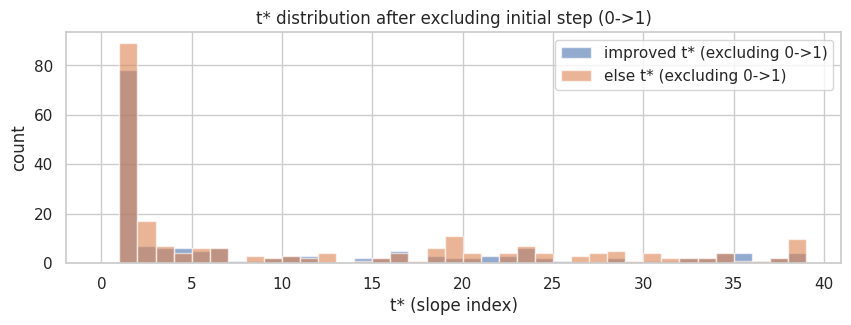

In [70]:
def per_patient_tstar_excluding_first(x_bt, mask_bt):
    x = x_bt.copy()
    x[~mask_bt] = np.nan
    dx = x[:, 1:] - x[:, :-1]  # slope index 0..T-2
    mask_s = mask_bt[:, 1:] & mask_bt[:, :-1]
    dx[~mask_s] = np.nan
    absdx = np.abs(dx)

    # exclude slope index 0 (0->1)
    absdx[:, 0] = np.nan

    tstar = np.nanargmax(absdx, axis=1)
    dpeak = np.nanmax(absdx, axis=1)
    return tstar, dpeak

tstar_imp2, _ = per_patient_tstar_excluding_first(ch3a[improved], valid_mask[improved])
tstar_else2, _ = per_patient_tstar_excluding_first(ch3a[else_], valid_mask[else_])

plt.figure(figsize=(10,3))
plt.hist(tstar_imp2, bins=np.arange(T), alpha=0.6, label="improved t* (excluding 0->1)")
plt.hist(tstar_else2, bins=np.arange(T), alpha=0.6, label="else t* (excluding 0->1)")
plt.title("t* distribution after excluding initial step (0->1)")
plt.xlabel("t* (slope index)")
plt.ylabel("count")
plt.legend()
plt.show()


모델은 대부분 환자에서 초기에 check3 채널 가중치를 올린다 (t*가 0에 몰림)

그 초기 상승폭이 improved에서 더 크다 (dpeak_val 효과크기+유의성)

초기 구간을 제거/교란하면 improved logit이 더 흔들린다 (faithfulness V4)

따라서 모델이 improved 판단에서 check3를 활용하는 방식은
“(언제) 초반 구간 + (얼마나) 급격한 주의 전환”으로 요약된다

### 초반 변화가 전부인가 vs 초반 말고도 신호가 있는가

In [71]:
# Cell 1) imports + helpers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu

# 네 파일에서 가져오기 (이미 있는 함수)
from check3_improved_feature_discovery import extract_tensors

def find_channel_index(check_names, target="check3"):
    target_l = target.lower().strip()
    for i, n in enumerate(check_names):
        if str(n).lower().strip() == target_l:
            return i
    for i, n in enumerate(check_names):
        if target_l in str(n).lower().strip():
            return i
    raise ValueError(f"{target} not found in check_names")

def smooth_1d(x, k=1):
    if k <= 1:
        return x
    if k % 2 == 0:
        k += 1
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    w = np.ones(k, dtype=np.float32) / float(k)
    return np.convolve(xp, w, mode="valid")

def masked_mean(x_bt, mask_bt):
    x = x_bt.astype(float).copy()
    x[~mask_bt] = np.nan
    return np.nanmean(x, axis=0)

def masked_slope_mean(x_bt, mask_bt):
    x = x_bt.astype(float).copy()
    x[~mask_bt] = np.nan
    dx = x[:, 1:] - x[:, :-1]
    mask_s = mask_bt[:, 1:] & mask_bt[:, :-1]
    dx[~mask_s] = np.nan
    return np.nanmean(dx, axis=0), dx, mask_s

def per_patient_dpeak_tstar(x_bt, mask_bt, smooth_k=1):
    """
    x_bt: (B,T) -> per patient max |Δ x| and its t*
    smooth applied per patient
    """
    B, T = x_bt.shape
    tstar = np.zeros(B, dtype=int)
    dpeak = np.zeros(B, dtype=float)

    for i in range(B):
        xi = x_bt[i].copy()
        mi = mask_bt[i].copy()

        # smooth only on valid region (간단 처리: nan 채우고 smooth 후 다시 nan)
        xi2 = xi.astype(float)
        xi2[~mi] = np.nan

        # nan 구간은 앞 값으로 채워서(혹은 0) smooth 영향 최소화
        # (mask가 길이형이라면 보통 뒤쪽만 nan이라 문제 적음)
        if np.all(np.isnan(xi2)):
            tstar[i] = 0
            dpeak[i] = np.nan
            continue

        # forward-fill
        for t in range(T):
            if np.isnan(xi2[t]):
                xi2[t] = xi2[t-1] if t > 0 else 0.0

        if smooth_k > 1:
            xi2 = smooth_1d(xi2, smooth_k)

        dx = xi2[1:] - xi2[:-1]  # (T-1)
        # slope valid mask
        ms = mi[1:] & mi[:-1]
        dx[~ms] = np.nan

        a = np.abs(dx)
        if np.all(np.isnan(a)):
            tstar[i] = 0
            dpeak[i] = np.nan
        else:
            tstar[i] = int(np.nanargmax(a))
            dpeak[i] = float(np.nanmax(a))
    return dpeak, tstar  # (B,), (B,)


In [72]:
# Cell 2) extract + basic tensors
split = "val"
smooth_k = 3          # 네가 쓰던 smoothing
improved_label = 0    # dPHQ==0

data = extract_tensors(batch, model, split=split)

ch_alpha = data["ch_alpha"]                    # (B,T,C) numpy
dPHQ     = data["dPHQ"].astype(int)            # (B,)
check_names = data["check_names"]

C_torch = data["C"]                            # torch (B,T,C)
C_np    = C_torch.detach().cpu().numpy()       # numpy (B,T,C)

B, T, Cc = ch_alpha.shape
ch3_idx = find_channel_index(check_names, "check3")

# group
g_imp = (dPHQ == improved_label)
g_else = ~g_imp

print("B,T,C =", B, T, Cc)
print("n improved / else =", g_imp.sum(), g_else.sum())
print("check3 idx =", ch3_idx, "| name =", check_names[ch3_idx])


B,T,C = 400 40 6
n improved / else = 172 228
check3 idx = 2 | name = check3


In [73]:
# Cell 3) valid_mask 만들기 (둘 중 하나)
# (A) 길이 정보가 있으면 이걸 쓰는 게 BEST
# lengths = batch.lengths[batch.idx_val]  # (B,) 같은 게 있다면!
# valid_mask = (np.arange(T)[None, :] < lengths[:, None])

# (B) padding이 "모든 채널이 0"일 때만 안전
valid_mask = (np.abs(C_np).sum(axis=2) > 0)  # (B,T)

print("valid ratio:", valid_mask.mean())
print("avg valid length:", valid_mask.sum(axis=1).mean())


valid ratio: 1.0
avg valid length: 40.0


In [74]:
# Cell 4) (핵심) "dpeak는 초반(0->1) 때문인가?" 점검 2종
# 1) 전체 dpeak vs else
ch3a = ch_alpha[:, :, ch3_idx]  # (B,T)

# smoothing을 dpeak 계산 내부에서 적용
dpeak_all, tstar_all = per_patient_dpeak_tstar(ch3a, valid_mask, smooth_k=smooth_k)

# 2) "초반 slope(0->1)를 제외"한 dpeak
#   => dx index 0이 0->1 이므로, argmax를 t>=1에서만 찾기
def dpeak_exclude_first_step(x_bt, mask_bt, smooth_k=1):
    B, T = x_bt.shape
    dpeak = np.zeros(B, float)
    tstar = np.zeros(B, int)
    for i in range(B):
        xi = x_bt[i].astype(float).copy()
        mi = mask_bt[i].copy()
        xi[~mi] = np.nan
        if np.all(np.isnan(xi)):
            dpeak[i] = np.nan
            tstar[i] = 1
            continue
        # fill
        for t in range(T):
            if np.isnan(xi[t]):
                xi[t] = xi[t-1] if t > 0 else 0.0
        if smooth_k > 1:
            xi = smooth_1d(xi, smooth_k)

        dx = xi[1:] - xi[:-1]        # (T-1), dx[0]=0->1
        ms = mi[1:] & mi[:-1]
        dx[~ms] = np.nan

        a = np.abs(dx)
        # exclude index 0
        a0 = a.copy()
        a0[0] = np.nan
        if np.all(np.isnan(a0)):
            dpeak[i] = np.nan
            tstar[i] = 1
        else:
            tstar[i] = int(np.nanargmax(a0))
            dpeak[i] = float(np.nanmax(a0))
    return dpeak, tstar

dpeak_ex0, tstar_ex0 = dpeak_exclude_first_step(ch3a, valid_mask, smooth_k=smooth_k)

# 비교 함수 (AUC + Mann-Whitney U)
def compare_binary(y_bin, score, title=""):
    y_bin = y_bin.astype(int)
    score = score.astype(float)
    m = np.isfinite(score)
    y_bin = y_bin[m]
    score = score[m]

    auc = roc_auc_score(y_bin, score) if len(np.unique(y_bin)) == 2 else np.nan
    # MWU: "분포가 다른가" (비모수)
    x1 = score[y_bin == 1]
    x0 = score[y_bin == 0]
    p = mannwhitneyu(x1, x0, alternative="two-sided").pvalue if (len(x1)>0 and len(x0)>0) else np.nan

    print(f"[{title}] AUC={auc:.4f} | MWU p={p:.3g} | mean(improved)={x1.mean():.4f} | mean(else)={x0.mean():.4f}")
    return auc, p

y_bin = (dPHQ == improved_label).astype(int)

compare_binary(y_bin, dpeak_all, title="dpeak_all = max |Δ ch3-attn| (all t)")
compare_binary(y_bin, dpeak_ex0, title="dpeak_ex0 = max |Δ ch3-attn| (exclude 0->1)")


[dpeak_all = max |Δ ch3-attn| (all t)] AUC=0.7610 | MWU p=3.86e-19 | mean(improved)=0.0335 | mean(else)=0.0256
[dpeak_ex0 = max |Δ ch3-attn| (exclude 0->1)] AUC=0.7551 | MWU p=2.35e-18 | mean(improved)=0.0331 | mean(else)=0.0254


(0.7551127090983271, np.float64(2.352086348264563e-18))

“check3에 대한 중요도의 평균 수준이 아니라, 반응의 강도(변화 폭)가 improved에서 더 크다”
check3-attention의 가장 큰 변화가 발생한 시점(t*)

improved / else 모두 거의 동일 (대부분 초반)

즉,

“언제 변했는가”는 집단을 가르지 못함

하지만,

“얼마나 크게 변했는가”는 집단을 가름

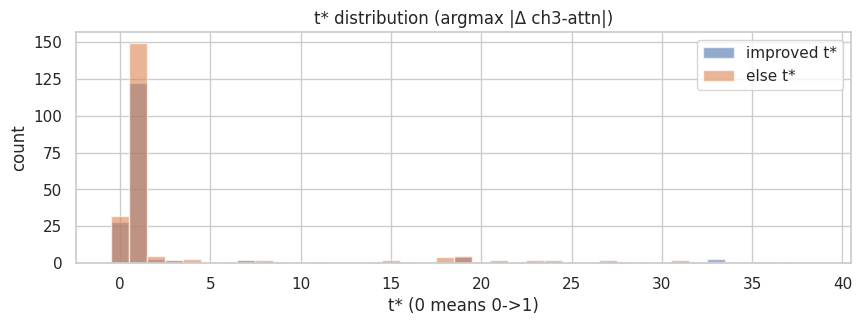

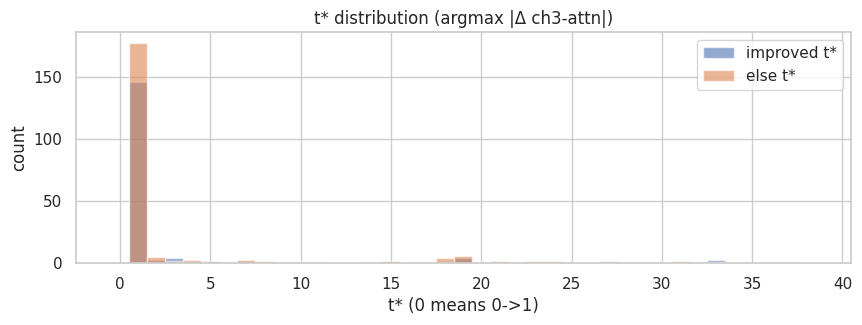

mode t* (all): improved= 1 else= 1
mode t* (ex0): improved= 1 else= 1


In [75]:
# Cell 5) "t* 분포" 자체가 구분 신호인가? (대부분 0이라면 위치는 신호 아님)
def plot_tstar_hist(tstar_imp, tstar_else, T):
    plt.figure(figsize=(10,3))
    bins = np.arange(0, T) - 0.5
    plt.hist(tstar_imp, bins=bins, alpha=0.6, label="improved t*")
    plt.hist(tstar_else, bins=bins, alpha=0.6, label="else t*")
    plt.title("t* distribution (argmax |Δ ch3-attn|)")
    plt.xlabel("t* (0 means 0->1)")
    plt.ylabel("count")
    plt.legend()
    plt.show()

plot_tstar_hist(tstar_all[g_imp], tstar_all[g_else], T)
plot_tstar_hist(tstar_ex0[g_imp], tstar_ex0[g_else], T)

print("mode t* (all): improved=", np.bincount(tstar_all[g_imp]).argmax(),
      "else=", np.bincount(tstar_all[g_else]).argmax())
print("mode t* (ex0): improved=", np.bincount(tstar_ex0[g_imp]).argmax(),
      "else=", np.bincount(tstar_ex0[g_else]).argmax())


In [76]:
# Cell 6) raw check3 자체가 다른가? (초기값/초기변화/전체요약)
c3_raw = C_np[:, :, ch3_idx]  # (B,T) raw input check3

# mask 적용해서 안정적인 요약 만들기
def masked_take_t(x_bt, mask_bt, t):
    x = x_bt.astype(float).copy()
    x[~mask_bt] = np.nan
    return x[:, t]

def masked_first_valid(x_bt, mask_bt):
    # 첫 valid timestep 값
    B, T = x_bt.shape
    out = np.full(B, np.nan)
    for i in range(B):
        idx = np.where(mask_bt[i])[0]
        if len(idx) > 0:
            out[i] = x_bt[i, idx[0]]
    return out

def masked_delta_0to1(x_bt, mask_bt):
    # 0->1이 둘 다 valid일 때만
    x = x_bt.astype(float).copy()
    x[~mask_bt] = np.nan
    dx01 = x[:, 1] - x[:, 0]
    ok = mask_bt[:, 0] & mask_bt[:, 1]
    dx01[~ok] = np.nan
    return dx01

# raw features
c3_t0      = masked_first_valid(c3_raw, valid_mask)         # 첫 valid 값(대개 t0)
c3_delta01 = masked_delta_0to1(c3_raw, valid_mask)          # 0->1 변화량
c3_mean    = np.nanmean(np.where(valid_mask, c3_raw, np.nan), axis=1)

compare_binary(y_bin, c3_t0,      title="raw check3: first valid value")
compare_binary(y_bin, c3_delta01, title="raw check3: delta (0->1)")
compare_binary(y_bin, c3_mean,    title="raw check3: mean over valid timesteps")


[raw check3: first valid value] AUC=0.5311 | MWU p=0.213 | mean(improved)=0.3775 | mean(else)=0.2516
[raw check3: delta (0->1)] AUC=0.4390 | MWU p=0.00494 | mean(improved)=-0.2824 | mean(else)=-0.0089
[raw check3: mean over valid timesteps] AUC=0.4527 | MWU p=0.104 | mean(improved)=-0.0684 | mean(else)=0.1189


(0.45272337821297426, np.float64(0.10419962024913153))

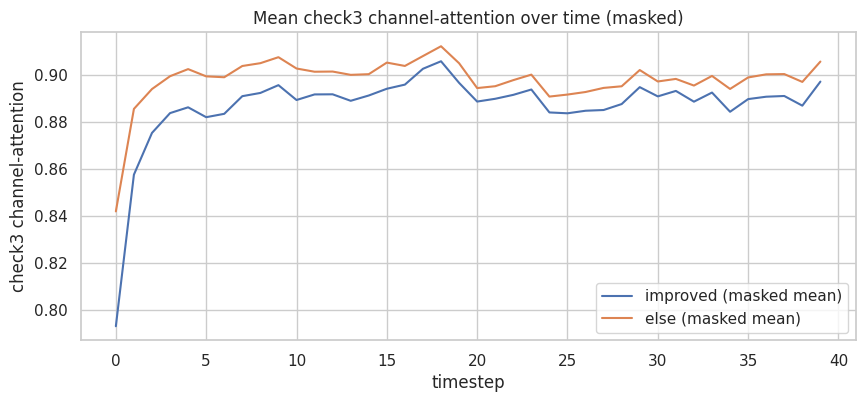

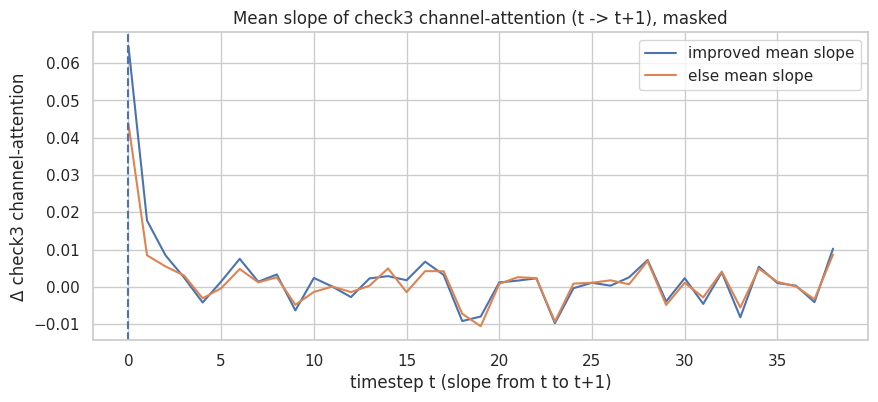

Top slope-gap segments (t -> t+1):
  t=0 -> 1 | gap=0.020911 | imp=0.064544 | else=0.043633
  t=1 -> 2 | gap=0.009311 | imp=0.017770 | else=0.008459
  t=10 -> 11 | gap=0.003752 | imp=0.002379 | else=-0.001372
  t=15 -> 16 | gap=0.003189 | imp=0.001764 | else=-0.001426
  t=2 -> 3 | gap=0.002968 | imp=0.008431 | else=0.005463


In [77]:
# Cell 7) 평균 곡선 재시각화 (masked) + slope gap top-k 확인
ch3a_s = ch3a.copy()
# smoothing은 시각화용으로만 적용(평균 계산 전에 개별 smoothing을 하려면 loop 필요)
# 여기선 간단하게: 그대로 masked mean, slope
m_imp = masked_mean(ch3a_s[g_imp], valid_mask[g_imp])
m_else = masked_mean(ch3a_s[g_else], valid_mask[g_else])

plt.figure(figsize=(10,4))
plt.plot(m_imp, label="improved (masked mean)")
plt.plot(m_else, label="else (masked mean)")
plt.title("Mean check3 channel-attention over time (masked)")
plt.xlabel("timestep")
plt.ylabel("check3 channel-attention")
plt.legend()
plt.show()

s_imp, dx_imp, ms_imp = masked_slope_mean(ch3a_s[g_imp], valid_mask[g_imp])
s_else, dx_else, ms_else = masked_slope_mean(ch3a_s[g_else], valid_mask[g_else])

plt.figure(figsize=(10,4))
plt.plot(s_imp, label="improved mean slope")
plt.plot(s_else, label="else mean slope")
plt.axvline(0, linestyle="--")
plt.title("Mean slope of check3 channel-attention (t -> t+1), masked")
plt.xlabel("timestep t (slope from t to t+1)")
plt.ylabel("Δ check3 channel-attention")
plt.legend()
plt.show()

gap = np.abs(s_imp - s_else)
# top 5 segments
topk = np.argsort(-np.nan_to_num(gap, nan=-1))[:5]
print("Top slope-gap segments (t -> t+1):")
for t in topk:
    print(f"  t={t} -> {t+1} | gap={gap[t]:.6f} | imp={s_imp[t]:.6f} | else={s_else[t]:.6f}")


In [78]:
# Cell 8) local ablation: check3의 특정 window만 교란해서 성능/로그릿 변화 확인
import torch
from sklearn.metrics import f1_score, accuracy_score

@torch.no_grad()
def forward_phq_logits(model, S, C, y0p, y0p4, y0lon):
    model.eval()
    logit_phq, _, _, _, _ = model.forward_multi(S, C, y0p, y0p4, y0lon)
    return logit_phq

def ablate_check3_window_local(C: torch.Tensor, ch3_idx: int, t0: int, t1: int, mode="set_patient_mean", seed=0):
    """
    C: (B,T,C)
    [t0, t1] 구간만 check3 입력을 교란
    """
    rng = np.random.default_rng(seed)
    C2 = C.clone()
    B, T, _ = C2.shape
    t0 = max(0, int(t0)); t1 = min(T-1, int(t1))
    if t0 > t1:
        return C2

    if mode == "set_patient_mean":
        mean_i = C2[:, :, ch3_idx].mean(dim=1, keepdim=True)  # (B,1)
        C2[:, t0:t1+1, ch3_idx] = mean_i.repeat(1, t1-t0+1)
    elif mode == "permute_within_window":
        for i in range(B):
            win = C2[i, t0:t1+1, ch3_idx].detach().cpu().numpy()
            perm = rng.permutation(len(win))
            C2[i, t0:t1+1, ch3_idx] = torch.tensor(win[perm], device=C2.device, dtype=C2.dtype)
    else:
        raise ValueError("mode must be set_patient_mean or permute_within_window")
    return C2

@torch.no_grad()
def eval_macro_f1_acc(model, S, C, y0p, y0p4, y0lon, y_true_np):
    logit = forward_phq_logits(model, S, C, y0p, y0p4, y0lon)
    pred = torch.argmax(logit, dim=1).detach().cpu().numpy().astype(int)
    y = np.asarray(y_true_np).astype(int)
    return {
        "acc": float(accuracy_score(y, pred)),
        "macro_f1": float(f1_score(y, pred, average="macro")),
    }

# tensors
S = data["S"]
C_in = data["C"]
y0p = data["y0p"]
y0p4 = data["y0p4"]
y0lon = data["y0lon"]
y_true = data["dPHQ"]  # 0/1/2

base = eval_macro_f1_acc(model, S, C_in, y0p, y0p4, y0lon, y_true)
print("BASE:", base)

# 0->1만 깨기: t=0..1
C_01 = ablate_check3_window_local(C_in, ch3_idx, t0=0, t1=1, mode="set_patient_mean", seed=0)
m01 = eval_macro_f1_acc(model, S, C_01, y0p, y0p4, y0lon, y_true)
print("ABLATE [0..1]:", m01, "| delta_macro_f1:", m01["macro_f1"] - base["macro_f1"])

# 2..5 같은 "초반 이후"도 비교
C_25 = ablate_check3_window_local(C_in, ch3_idx, t0=2, t1=5, mode="set_patient_mean", seed=0)
m25 = eval_macro_f1_acc(model, S, C_25, y0p, y0p4, y0lon, y_true)
print("ABLATE [2..5]:", m25, "| delta_macro_f1:", m25["macro_f1"] - base["macro_f1"])

# 10..13 같은 중반도 비교
C_1013 = ablate_check3_window_local(C_in, ch3_idx, t0=10, t1=13, mode="set_patient_mean", seed=0)
m1013 = eval_macro_f1_acc(model, S, C_1013, y0p, y0p4, y0lon, y_true)
print("ABLATE [10..13]:", m1013, "| delta_macro_f1:", m1013["macro_f1"] - base["macro_f1"])


BASE: {'acc': 0.5025, 'macro_f1': 0.34569058227070215}
ABLATE [0..1]: {'acc': 0.505, 'macro_f1': 0.34719465854371473} | delta_macro_f1: 0.0015040762730125778
ABLATE [2..5]: {'acc': 0.505, 'macro_f1': 0.34719465854371473} | delta_macro_f1: 0.0015040762730125778
ABLATE [10..13]: {'acc': 0.505, 'macro_f1': 0.34719465854371473} | delta_macro_f1: 0.0015040762730125778


In [79]:
import numpy as np
import matplotlib.pyplot as plt

# ch3a: (B,T) check3 channel-attention
# valid_mask: (B,T)
# improved: (B,) boolean

def per_patient_tstar(x_bt, mask_bt):
    """
    x_bt: (B,T)
    mask_bt: (B,T) boolean
    returns:
      tstar: (B,) argmax |Δx|
      dpeak: (B,) max |Δx|
    """
    x = x_bt.copy()
    x[~mask_bt] = np.nan
    dx = x[:, 1:] - x[:, :-1]  # (B, T-1)
    mask_s = mask_bt[:, 1:] & mask_bt[:, :-1]
    dx[~mask_s] = np.nan

    absdx = np.abs(dx)
    tstar = np.nanargmax(absdx, axis=1)
    dpeak = np.nanmax(absdx, axis=1)
    return tstar, dpeak

tstar_imp, dpeak_imp = per_patient_tstar(ch3a[improved], valid_mask[improved])
tstar_else, dpeak_else = per_patient_tstar(ch3a[else_], valid_mask[else_])


In [80]:
T = ch3a.shape[1]
counts_imp = np.bincount(tstar_imp, minlength=T-1)
counts_else = np.bincount(tstar_else, minlength=T-1)


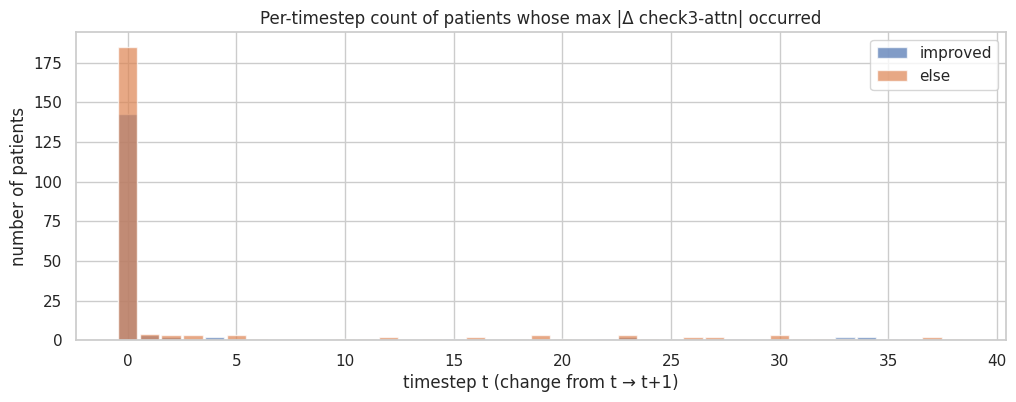

In [81]:
plt.figure(figsize=(12,4))
plt.bar(np.arange(T-1), counts_imp, alpha=0.7, label="improved", width=0.9)
plt.bar(np.arange(T-1), counts_else, alpha=0.7, label="else", width=0.9, bottom=counts_imp*0)
plt.title("Per-timestep count of patients whose max |Δ check3-attn| occurred")
plt.xlabel("timestep t (change from t → t+1)")
plt.ylabel("number of patients")
plt.legend()
plt.show()


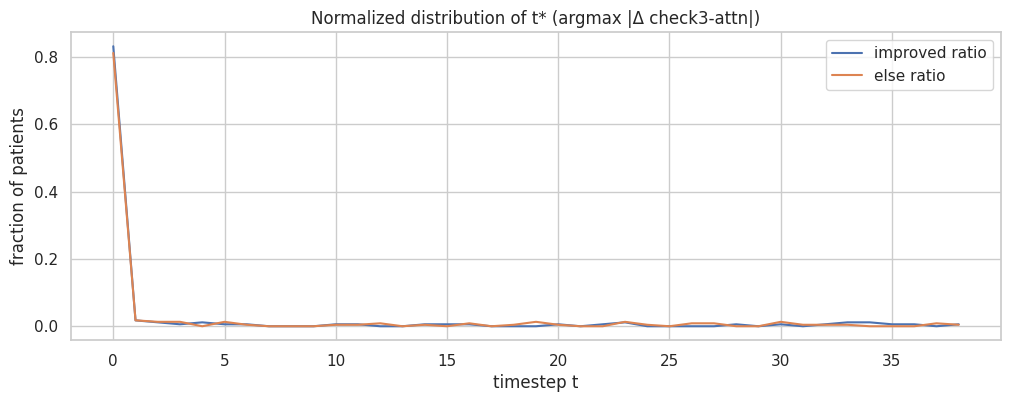

In [82]:
ratio_imp = counts_imp / counts_imp.sum()
ratio_else = counts_else / counts_else.sum()

plt.figure(figsize=(12,4))
plt.plot(ratio_imp, label="improved ratio")
plt.plot(ratio_else, label="else ratio")
plt.title("Normalized distribution of t* (argmax |Δ check3-attn|)")
plt.xlabel("timestep t")
plt.ylabel("fraction of patients")
plt.legend()
plt.show()


모델은 “check3가 들어오면 얼마나 강하게 내부 가중치를 재조정해야 하는가”를
환자별로 다르게 판단했고,
그 ‘조정 강도’가 outcome과 연결되어 있다.